In [1]:
# Cell 1 — Imports, paths, and configuration
# -*- coding: utf-8 -*-
"""
Final Production Notebook
CIGS Absorber Thickness Optimization
Blind-validated coupled optical–electrical model
"""

import os
import re
import glob
import csv
import numpy as np
import matplotlib.pyplot as plt

from scipy.interpolate import RegularGridInterpolator

# ============================================================
# Optional Google Drive mount
# ============================================================
USE_GOOGLE_DRIVE = True

if USE_GOOGLE_DRIVE:
    from google.colab import drive
    drive.mount('/content/drive')

# ============================================================
# Paths
# ============================================================
# For Colab + Google Drive:
PROJECT_PATH = "/content/drive/MyDrive/Colab Notebooks/PV_Layer_Opt"

# Folder containing Paulson CSV files
CIGS_FOLDER = os.path.join(PROJECT_PATH, "Refracive_index", "CIGS")

# Output folders
FIG_DIR = os.path.join(PROJECT_PATH, "Figures_FINAL")
RESULTS_DIR = os.path.join(PROJECT_PATH, "Results_FINAL")

os.makedirs(FIG_DIR, exist_ok=True)
os.makedirs(RESULTS_DIR, exist_ok=True)

print("CIGS data folder:", CIGS_FOLDER)
print("Figure output folder:", FIG_DIR)
print("Results output folder:", RESULTS_DIR)


Mounted at /content/drive
CIGS data folder: /content/drive/MyDrive/Colab Notebooks/PV_Layer_Opt/Refracive_index/CIGS
Figure output folder: /content/drive/MyDrive/Colab Notebooks/PV_Layer_Opt/Figures_FINAL
Results output folder: /content/drive/MyDrive/Colab Notebooks/PV_Layer_Opt/Results_FINAL


In [2]:
# Cell 2 — Physical constants and fixed parameters
# ============================================================
# Physical constants
# ============================================================
q   = 1.602176634e-19      # C
h   = 6.62607015e-34       # J s
c   = 299792458.0          # m/s
kB  = 1.380649e-23         # J/K
T   = 300.0                # K
kT  = kB * T
Vth = kT / q               # thermal voltage, V

# ============================================================
# Device / model parameters
# ============================================================
# Optical stack
ALPHA_CdS_CM  = 1.0e5      # cm^-1, below CdS cutoff
CdS_CUTOFF_NM = 520.0      # nm
T_CdS_NM      = 50.0       # nm
R_BACK        = 0.75       # Mo broadband reflectance

# Transport
W_DEP       = 0.25e-6      # 250 nm depletion width
S_BACK_CM_S = 1.0e5       # cm/s
MU_N_CM2VS  = 100.0       # cm^2/V/s
D_N_M2S     = MU_N_CM2VS * Vth * 1e-4  # m^2/s

# Diode / electrical
R_S_CM2     = 0.5
R_S_SI      = R_S_CM2 * 1e-4
N_IDEALITY  = 1.5
J00_REF     = 4.0e8       # A/m^2, single calibration at x≈0.30

# Urbach correction
URBACH_EU_eV = 0.020      # 20 meV

# Final recombination model
FINAL_FORM = "quadratic"
FINAL_APEN = 1.0

# Thickness / diffusion length grids
thickness_um = np.linspace(0.05, 6.0, 500)
thickness_m  = thickness_um * 1e-6
L_um_list    = [0.3, 0.7, 1.5, 3.0]

print("Thermal voltage Vth =", Vth)
print("Electron diffusion coefficient D_n =", D_N_M2S * 1e4, "cm^2/s")


Thermal voltage Vth = 0.025851999786435535
Electron diffusion coefficient D_n = 2.5851999786435536 cm^2/s


Integrated AM1.5g power = 840.3237128274156 W/m^2


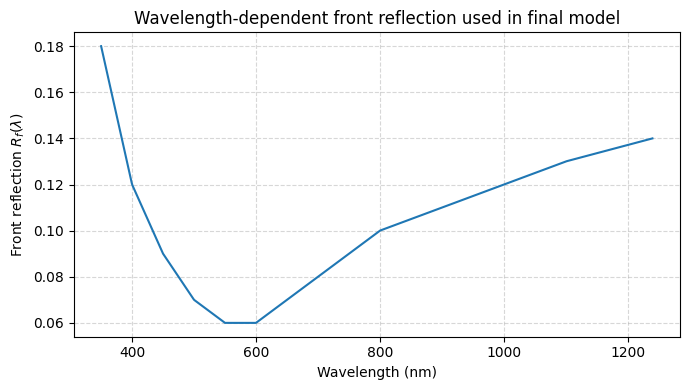

In [3]:
# Cell 3 — AM1.5g spectrum and optical-stack functions
# ============================================================
# AM1.5g spectrum through Solcore
# ============================================================
try:
    from solcore.light_source import LightSource
except ImportError:
    import subprocess
    subprocess.run(["pip", "install", "solcore", "-q"], check=False)
    from solcore.light_source import LightSource

wl_nm = np.linspace(350.0, 1240.0, 900)
wl_m  = wl_nm * 1e-9

light = LightSource(source_type="standard", version="AM1.5g", x=wl_nm)
spec = light.spectrum(wl_nm)
I_nm = np.asarray(spec[1] if isinstance(spec, tuple) else spec).ravel()  # W/m^2/nm

E_ph = h * c / wl_m
phi_per_nm = I_nm / E_ph  # photons / m^2 / s / nm
P_IN = float(np.trapezoid(I_nm, wl_nm))

print("Integrated AM1.5g power =", P_IN, "W/m^2")

# ============================================================
# CdS transmission
# ============================================================
T_CdS_lambda = np.where(
    wl_nm < CdS_CUTOFF_NM,
    np.exp(-ALPHA_CdS_CM * 100.0 * T_CdS_NM * 1e-9),
    1.0
)

# ============================================================
# Wavelength-dependent front reflection
# Digitized/simplified TMM-like front reflection for ZnO/i-ZnO/CdS
# ============================================================
_wl_ref = np.array([350, 400, 450, 500, 550, 600, 650, 700,
                    800, 900, 1000, 1100, 1240])

_R_ref = np.array([0.18, 0.12, 0.09, 0.07, 0.06, 0.06, 0.07,
                   0.08, 0.10, 0.11, 0.12, 0.13, 0.14])

R_FRONT_lambda_TMM = np.interp(wl_nm, _wl_ref, _R_ref)

plt.figure(figsize=(7, 4))
plt.plot(wl_nm, R_FRONT_lambda_TMM)
plt.xlabel("Wavelength (nm)")
plt.ylabel("Front reflection $R_f(\\lambda)$")
plt.title("Wavelength-dependent front reflection used in final model")
plt.grid(True, linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()


In [4]:
# Cell 4 — Load and interpolate Paulson optical data
# ============================================================
# Parse Paulson optical data
# ============================================================
_num_re = re.compile(r"[-+]?\d*\.?\d+(?:[eE][-+]?\d+)?")

def parse_paulson_csv(filepath):
    """
    Expected columns from parsed text:
    nums[0] = wavelength in nm
    nums[4] = absorption coefficient in cm^-1
    """
    wl, alpha = [], []

    with open(filepath, "r", encoding="latin1", errors="ignore") as f:
        for line in f:
            nums = _num_re.findall(line)
            if len(nums) < 5:
                continue

            try:
                wl0 = float(nums[0])
                a0  = float(nums[4])
            except ValueError:
                continue

            if wl0 <= 0 or a0 < 0:
                continue

            wl.append(wl0)
            alpha.append(a0)

    if len(wl) < 10:
        raise ValueError(f"Too few valid data points in {filepath}")

    wl = np.array(wl)
    alpha = np.array(alpha)
    order = np.argsort(wl)

    return wl[order], alpha[order]


def parse_x_from_filename(fname):
    m = re.search(r"x\s*=\s*([0-9]*\.?[0-9]+)", fname)
    if not m:
        raise ValueError(f"Cannot parse x from filename: {fname}")
    return float(m.group(1))


file_paths = sorted(glob.glob(os.path.join(CIGS_FOLDER, "*.csv")))

if not file_paths:
    raise FileNotFoundError(
        f"No CSV files found in {CIGS_FOLDER}. "
        "Place Paulson optical-constant CSV files there."
    )

files = []
for fp in file_paths:
    try:
        x = parse_x_from_filename(os.path.basename(fp))
        files.append((x, fp))
    except ValueError:
        continue

files.sort(key=lambda t: t[0])
x_vals = [t[0] for t in files]

print("Loaded compositions x =", x_vals)

# Interpolate alpha(lambda) for each measured composition
alpha_dict = {}

for x, fp in files:
    wl_data, alpha_cm = parse_paulson_csv(fp)
    alpha_dict[x] = np.interp(wl_nm, wl_data, alpha_cm) * 100.0  # cm^-1 -> m^-1

# 2D interpolation alpha(lambda, x)
x_arr = np.array(x_vals)
alpha_mat = np.stack([alpha_dict[x] for x in x_vals], axis=0)

alpha_interp = RegularGridInterpolator(
    (x_arr, wl_nm),
    alpha_mat,
    bounds_error=False,
    fill_value=None,
    method="linear"
)

print("alpha interpolation grid:", alpha_mat.shape)


Loaded compositions x = [0.0, 0.31, 0.45, 0.66, 1.0]
alpha interpolation grid: (5, 900)


In [5]:
# Cell 5 — Bandgap, Urbach correction, optics, collection, diode model
# ============================================================
# Composition-dependent bandgap
# ============================================================
def bandgap(x):
    """
    CIGS bandgap in eV.
    Eg(x) = 1.01 + 0.626x - 0.167x(1-x)
    """
    return 1.01 + 0.626 * x - 0.167 * x * (1.0 - x)


# ============================================================
# Urbach correction
# ============================================================
def apply_urbach_cutoff(alpha_m, x, Eu=URBACH_EU_eV):
    """
    Force sub-bandgap absorption to decay exponentially with Urbach energy.
    """
    Eg = bandgap(x)
    E_ph_eV = 1240.0 / wl_nm
    sub_bg = E_ph_eV < Eg

    if not np.any(sub_bg):
        return alpha_m

    idx_anchor = int(np.argmin(np.abs(E_ph_eV - Eg)))
    alpha_anchor = alpha_m[idx_anchor]

    alpha_urbach = alpha_anchor * np.exp((E_ph_eV - Eg) / Eu)

    return np.where(sub_bg, np.minimum(alpha_m, alpha_urbach), alpha_m)


def alpha_for_x(x_query):
    """
    Return alpha(lambda, x_query) in m^-1 on wl_nm grid.
    """
    x_clip = float(np.clip(x_query, x_arr.min(), x_arr.max()))
    pts = np.column_stack([np.full_like(wl_nm, x_clip), wl_nm])
    a = alpha_interp(pts)
    a = apply_urbach_cutoff(a, x_query)
    return np.clip(a, 0.0, None)


# ============================================================
# Two-pass absorption
# ============================================================
def absorptance_two_pass(alpha_m, d, R_front_l=None, R_back=R_BACK):
    """
    Planar incoherent two-pass absorption:
    A = (1-Rf) T_CdS [(1-exp(-alpha d)) + Rb exp(-alpha d)(1-exp(-alpha d))]
    """
    if R_front_l is None:
        R_front_l = R_FRONT_lambda_TMM

    exp_ad = np.exp(-alpha_m * d)
    first = 1.0 - exp_ad
    second = R_back * exp_ad * first

    return (1.0 - R_front_l) * T_CdS_lambda * (first + second)


# ============================================================
# Patched Hegedus-Shafarman / Gaertner collection
# ============================================================
def gaertner_collection(alpha_m, d, W=W_DEP, L=1.0e-6,
                        S_b_cm_s=S_BACK_CM_S, D=D_N_M2S):
    """
    Spectral collection efficiency with numerical guards.

    Drift collection in depletion region:
        eta_drift = 1 - exp(-alpha W)

    Diffusion collection in quasi-neutral region:
        Hegedus-Shafarman / Gaertner analytical expression
        with finite back-surface recombination velocity.
    """
    Wn = max(d - W, 0.0)

    eta_drift = 1.0 - np.exp(-alpha_m * W)

    if Wn <= 0.0:
        return np.clip(eta_drift, 0.0, 1.0)

    S_b_m_s = S_b_cm_s * 1e-2

    aL = alpha_m * L
    SL_D = S_b_m_s * L / D

    arg = np.clip(Wn / L, 0.0, 50.0)
    coshW = np.cosh(arg)
    sinhW = np.sinh(arg)

    ratio_expD_over_expW = np.exp(-alpha_m * Wn)

    numer = (SL_D + aL) - ratio_expD_over_expW * (SL_D * coshW + sinhW)
    denom = SL_D * sinhW + coshW

    safe = aL * aL - 1.0
    safe = np.where(np.abs(safe) < 1e-6, 1e-6 * np.sign(safe + 1e-30), safe)

    eta_qnr = np.exp(-alpha_m * W) * (aL / safe) * (aL - numer / denom)
    total = eta_drift + eta_qnr

    return np.clip(
        np.nan_to_num(total, nan=0.0, posinf=1.0, neginf=0.0),
        0.0,
        1.0
    )


# ============================================================
# S-Q current limit audit
# ============================================================
def SQ_Jsc_limit(Eg_eV):
    """
    S-Q Jsc limit over same AM1.5g wavelength grid.
    Returns A/m^2.
    """
    lam_g = 1240.0 / Eg_eV
    mask = wl_nm <= lam_g
    return q * float(np.trapezoid(phi_per_nm[mask], wl_nm[mask]))


# ============================================================
# Diode and FF
# ============================================================
def saturation_current(x, n=N_IDEALITY):
    return J00_REF * np.exp(-bandgap(x) * q / (n * kT))


def fill_factor_green(Voc, Jsc, R_s=R_S_SI, n=N_IDEALITY):
    """
    Green empirical FF with dimensionless series resistance.
    """
    if Voc <= 0.0:
        return 0.0

    v_oc = Voc / (n * Vth)

    if v_oc < 10.0:
        return 0.0

    FF0 = (v_oc - np.log(v_oc + 0.72)) / (v_oc + 1.0)
    r_s = R_s * Jsc / Voc

    FF = FF0 * max(0.0, 1.0 - r_s)

    return float(np.clip(FF, 0.0, 0.89))


In [6]:
# Cell 6 — Final device model and model-form comparison tools
# ============================================================
# Final generalized device model
# ============================================================
def device_metrics_model(x, d, L_um,
                         form="quadratic",
                         alpha_pen=1.0,
                         W=W_DEP,
                         S_b=S_BACK_CM_S,
                         n=N_IDEALITY,
                         R_s=R_S_SI,
                         R_back=R_BACK,
                         R_front_l=None):
    """
    Final coupled optical-electrical model.

    form:
        linear    : J0_eff = J0 * [1 + alpha_pen * d/L]
        quadratic : J0_eff = J0 * [1 + alpha_pen * (d/L)^2]
        shockley  : J0_eff = J0 * [1 + alpha_pen * (d/L)coth(d/L)]
    """
    alpha_m = alpha_for_x(x)
    L_m = L_um * 1e-6

    if R_front_l is None:
        R_front_l = R_FRONT_lambda_TMM

    A_opt = absorptance_two_pass(alpha_m, d, R_front_l=R_front_l, R_back=R_back)
    IQE = gaertner_collection(alpha_m, d, W=W, L=L_m, S_b_cm_s=S_b)
    EQE = A_opt * IQE

    Jsc = q * float(np.trapezoid(EQE * phi_per_nm, wl_nm))

    ratio = d / L_m

    if form == "linear":
        scaling = 1.0 + alpha_pen * ratio
    elif form == "quadratic":
        scaling = 1.0 + alpha_pen * ratio**2
    elif form == "shockley":
        coth = 1.0 / np.tanh(np.clip(ratio, 1e-3, 50.0))
        scaling = 1.0 + alpha_pen * ratio * coth
    else:
        raise ValueError(f"Unknown recombination form: {form}")

    J0_eff = saturation_current(x, n=n) * scaling

    Voc = n * Vth * np.log(Jsc / J0_eff + 1.0) if Jsc > 0 else 0.0
    FF = fill_factor_green(Voc, Jsc, R_s=R_s, n=n)
    eta = 100.0 * Jsc * Voc * FF / P_IN

    return {
        "Jsc": Jsc,
        "Voc": Voc,
        "FF": FF,
        "eta": eta,
        "EQE": EQE,
        "A_opt": A_opt,
        "IQE": IQE
    }


def predict_optimum(x, L_um, form="quadratic", alpha_pen=1.0):
    arr_eta = np.zeros_like(thickness_m)

    for i, d in enumerate(thickness_m):
        r = device_metrics_model(
            x=x,
            d=d,
            L_um=L_um,
            form=form,
            alpha_pen=alpha_pen
        )
        arr_eta[i] = r["eta"]

    idx = int(np.argmax(arr_eta))

    return thickness_um[idx], arr_eta[idx]


# ============================================================
# Validation set
# ============================================================
experiments = [
    (0.00, 0.8, 1.8, 12.0, "Lundberg 2003 (CIS)"),
    (0.30, 1.5, 1.8, 20.3, "Jackson 2011"),
    (0.30, 2.5, 2.0, 22.6, "Jackson 2016"),
    (0.30, 1.0, 1.5, 17.0, "Gloeckler 2005"),
    (0.30, 1.5, 2.0, 21.0, "Ramanujam 2017"),
]


In [7]:
# Cell 7 — Model-form comparison: linear vs quadratic vs Shockley coth
# ============================================================
# Model-form comparison
# ============================================================
def combined_cost(form, alpha_pen):
    err_d = []
    err_eta = []

    for x_e, L_e, d_e, eta_e, src in experiments:
        d_pred, eta_pred = predict_optimum(
            x=x_e,
            L_um=L_e,
            form=form,
            alpha_pen=alpha_pen
        )

        err_d.append(abs(d_pred - d_e) / d_e)
        err_eta.append(abs(eta_pred - eta_e) / eta_e)

    return (
        0.5 * np.mean(err_d) + 0.5 * np.mean(err_eta),
        np.mean(err_d),
        np.mean(err_eta)
    )


forms = ["linear", "quadratic", "shockley"]
alpha_grid = np.linspace(0.2, 8.0, 40)

best_per_form = {}

print("=" * 95)
print("MODEL-FORM COMPARISON")
print("=" * 95)
print(f"{'Form':<12s} {'Best alpha':>12s} {'Cost':>12s} {'MAE_d (%)':>12s} {'MAE_eta (%)':>14s}")
print("-" * 95)

for form in forms:
    grid_results = [combined_cost(form, a) for a in alpha_grid]
    costs = [r[0] for r in grid_results]
    idx = int(np.argmin(costs))

    best_alpha = float(alpha_grid[idx])
    cost, mae_d_rel, mae_eta_rel = grid_results[idx]

    best_per_form[form] = (best_alpha, cost, mae_d_rel, mae_eta_rel)

    print(f"{form:<12s} {best_alpha:12.2f} {cost:12.4f} {100*mae_d_rel:12.1f} {100*mae_eta_rel:14.1f}")

winner_form = min(best_per_form, key=lambda f: best_per_form[f][1])
winner_alpha = best_per_form[winner_form][0]

print("\nWinner:", winner_form, "alpha =", winner_alpha)

# Save model-form comparison
form_csv = os.path.join(RESULTS_DIR, "model_form_comparison.csv")
with open(form_csv, "w", newline="", encoding="utf-8") as f:
    writer = csv.writer(f)
    writer.writerow(["form", "best_alpha", "combined_cost", "MAE_d_percent", "MAE_eta_percent"])
    for form in forms:
        a, cost, ed, ee = best_per_form[form]
        writer.writerow([form, a, cost, 100*ed, 100*ee])

print("Saved:", form_csv)


MODEL-FORM COMPARISON
Form           Best alpha         Cost    MAE_d (%)    MAE_eta (%)
-----------------------------------------------------------------------------------------------
linear               4.60       0.1788         20.1           15.7
quadratic            1.00       0.1340         15.1           11.7
shockley             3.40       0.2714         40.2           14.0

Winner: quadratic alpha = 1.0
Saved: /content/drive/MyDrive/Colab Notebooks/PV_Layer_Opt/Results_FINAL/model_form_comparison.csv


In [8]:
# Cell 8 — Final validation with quadratic model
# ============================================================
# Final blind validation using production model
# ============================================================
final_validation = []

print("=" * 110)
print("FINAL BLIND VALIDATION: quadratic J0, alpha_pen = 1.0")
print("=" * 110)
print(f"{'Source':28s} {'x':>5s} {'L':>6s} {'d_exp':>8s} {'d_pred':>8s} "
      f"{'err%':>8s} {'eta_exp':>9s} {'eta_pred':>10s} {'Delta_eta':>10s}")
print("-" * 110)

for x_e, L_e, d_e, eta_e, src in experiments:
    arr_eta = np.zeros_like(thickness_m)

    for i, d in enumerate(thickness_m):
        r = device_metrics_model(
            x=x_e,
            d=d,
            L_um=L_e,
            form="quadratic",
            alpha_pen=1.0
        )
        arr_eta[i] = r["eta"]

    idx = int(np.argmax(arr_eta))
    d_pred = thickness_um[idx]
    eta_pred = arr_eta[idx]
    err_percent = 100.0 * abs(d_pred - d_e) / d_e
    delta_eta = eta_pred - eta_e

    final_validation.append(
        (src, x_e, L_e, d_e, d_pred, err_percent, eta_e, eta_pred, delta_eta)
    )

    print(f"{src:28s} {x_e:5.2f} {L_e:6.2f} {d_e:8.2f} {d_pred:8.2f} "
          f"{err_percent:8.1f} {eta_e:9.2f} {eta_pred:10.2f} {delta_eta:10.2f}")

mae_d = np.mean([r[5] for r in final_validation])
mae_eta_pp = np.mean([abs(r[8]) for r in final_validation])
rmse_eta_pp = np.sqrt(np.mean([r[8]**2 for r in final_validation]))

print("\nFinal validation metrics")
print("MAE d_opt =", mae_d, "%")
print("MAE eta   =", mae_eta_pp, "pp")
print("RMSE eta  =", rmse_eta_pp, "pp")

# Save validation table
validation_csv = os.path.join(RESULTS_DIR, "final_validation.csv")
with open(validation_csv, "w", newline="", encoding="utf-8") as f:
    writer = csv.writer(f)
    writer.writerow(["source", "x", "L_um", "d_exp_um", "d_pred_um",
                     "err_percent", "eta_exp_percent", "eta_pred_percent", "delta_eta_pp"])
    writer.writerows(final_validation)

print("Saved:", validation_csv)


FINAL BLIND VALIDATION: quadratic J0, alpha_pen = 1.0
Source                           x      L    d_exp   d_pred     err%   eta_exp   eta_pred  Delta_eta
--------------------------------------------------------------------------------------------------------------
Lundberg 2003 (CIS)           0.00   0.80     1.80     1.10     38.9     12.00      12.98       0.98
Jackson 2011                  0.30   1.50     1.80     1.79      0.5     20.30      17.59      -2.71
Jackson 2016                  0.30   2.50     2.00     2.38     18.8     22.60      18.18      -4.42
Gloeckler 2005                0.30   1.00     1.50     1.40      6.8     17.00      17.22       0.22
Ramanujam 2017                0.30   1.50     2.00     1.79     10.5     21.00      17.59      -3.41

Final validation metrics
MAE d_opt = 15.097639723892218 %
MAE eta   = 2.345531310671656 pp
RMSE eta  = 2.809192775174653 pp
Saved: /content/drive/MyDrive/Colab Notebooks/PV_Layer_Opt/Results_FINAL/final_validation.csv


In [9]:
# Cell 9 — Final S-Q audit using final model
# ============================================================
# Final S-Q audit using production model
# ============================================================
sq_rows = []
n_violations = 0

print("=" * 95)
print("FINAL S-Q AUDIT")
print("=" * 95)
print(f"{'x':>5s} {'L_um':>6s} {'d_um':>6s} {'Jsc_raw':>10s} {'Jsc_SQ':>10s} {'ratio':>8s} {'flag':>6s}")
print("-" * 95)

for x in [0.00, 1.00]:
    for L_um in [0.3, 1.5, 3.0]:
        for d_um in [0.5, 1.5, 3.0]:
            r = device_metrics_model(
                x=x,
                d=d_um * 1e-6,
                L_um=L_um,
                form="quadratic",
                alpha_pen=1.0
            )

            Jsc_raw = r["Jsc"] * 0.1  # A/m^2 -> mA/cm^2
            Jsc_SQ = SQ_Jsc_limit(bandgap(x)) * 0.1
            ratio = Jsc_raw / Jsc_SQ
            flag = "ok" if ratio <= 1.0 else "CAP"

            if flag != "ok":
                n_violations += 1

            sq_rows.append((x, L_um, d_um, Jsc_raw, Jsc_SQ, ratio, flag))

            print(f"{x:5.2f} {L_um:6.2f} {d_um:6.2f} "
                  f"{Jsc_raw:10.2f} {Jsc_SQ:10.2f} {ratio:8.3f} {flag:>6s}")

print(f"\nS-Q violations: {n_violations} / {len(sq_rows)}")

# Save S-Q audit
sq_csv = os.path.join(RESULTS_DIR, "SQ_audit_final.csv")
with open(sq_csv, "w", newline="", encoding="utf-8") as f:
    writer = csv.writer(f)
    writer.writerow(["x", "L_um", "d_um", "Jsc_raw_mAcm2", "Jsc_SQ_mAcm2", "ratio", "flag"])
    writer.writerows(sq_rows)

print("Saved:", sq_csv)


FINAL S-Q AUDIT
    x   L_um   d_um    Jsc_raw     Jsc_SQ    ratio   flag
-----------------------------------------------------------------------------------------------
 0.00   0.30   0.50      30.28      47.26    0.641     ok
 0.00   0.30   1.50      31.85      47.26    0.674     ok
 0.00   0.30   3.00      31.99      47.26    0.677     ok
 0.00   1.50   0.50      31.15      47.26    0.659     ok
 0.00   1.50   1.50      37.49      47.26    0.793     ok
 0.00   1.50   3.00      39.70      47.26    0.840     ok
 0.00   3.00   0.50      30.91      47.26    0.654     ok
 0.00   3.00   1.50      36.73      47.26    0.777     ok
 0.00   3.00   3.00      38.98      47.26    0.825     ok
 1.00   0.30   0.50      15.60      24.17    0.645     ok
 1.00   0.30   1.50      16.37      24.17    0.677     ok
 1.00   0.30   3.00      16.47      24.17    0.681     ok
 1.00   1.50   0.50      15.43      24.17    0.638     ok
 1.00   1.50   1.50      18.51      24.17    0.766     ok
 1.00   1.50   3.0

In [10]:
# Cell 10 — Final sweep over x,L and thickness
# ============================================================
# Final sweep over all compositions and diffusion lengths
# ============================================================
results_final = {L: {} for L in L_um_list}
optima_final = {L: {} for L in L_um_list}

for L_um in L_um_list:
    for x in x_vals:
        arr_Jsc = np.zeros_like(thickness_m)
        arr_Voc = np.zeros_like(thickness_m)
        arr_FF  = np.zeros_like(thickness_m)
        arr_eta = np.zeros_like(thickness_m)

        for i, d in enumerate(thickness_m):
            r = device_metrics_model(
                x=x,
                d=d,
                L_um=L_um,
                form="quadratic",
                alpha_pen=1.0
            )

            arr_Jsc[i] = r["Jsc"]
            arr_Voc[i] = r["Voc"]
            arr_FF[i]  = r["FF"]
            arr_eta[i] = r["eta"]

        results_final[L_um][x] = {
            "Jsc": arr_Jsc,
            "Voc": arr_Voc,
            "FF": arr_FF,
            "eta": arr_eta
        }

        idx = int(np.argmax(arr_eta))

        optima_final[L_um][x] = {
            "d_opt": thickness_um[idx],
            "eta_max": arr_eta[idx],
            "Jsc_mAcm2": arr_Jsc[idx] * 0.1,
            "Voc": arr_Voc[idx],
            "FF": arr_FF[idx]
        }

# Print and save final design table
design_rows = []

print("=" * 90)
print("FINAL DESIGN-POINT TABLE")
print("=" * 90)
print(f"{'L_um':>6s} {'x':>6s} {'d_opt':>8s} {'eta':>8s} {'Jsc':>9s} {'Voc':>8s} {'FF':>7s}")
print("-" * 90)

for L_um in L_um_list:
    for x in x_vals:
        o = optima_final[L_um][x]

        row = [
            L_um, x, o["d_opt"], o["eta_max"],
            o["Jsc_mAcm2"], o["Voc"], o["FF"]
        ]
        design_rows.append(row)

        print(f"{L_um:6.2f} {x:6.2f} {o['d_opt']:8.3f} {o['eta_max']:8.2f} "
              f"{o['Jsc_mAcm2']:9.2f} {o['Voc']:8.3f} {o['FF']:7.3f}")

design_csv = os.path.join(RESULTS_DIR, "final_design_points.csv")
with open(design_csv, "w", newline="", encoding="utf-8") as f:
    writer = csv.writer(f)
    writer.writerow(["L_um", "x", "d_opt_um", "eta_percent", "Jsc_mAcm2", "Voc_V", "FF"])
    writer.writerows(design_rows)

print("Saved:", design_csv)


FINAL DESIGN-POINT TABLE
  L_um      x    d_opt      eta       Jsc      Voc      FF
------------------------------------------------------------------------------------------
  0.30   0.00    0.491    10.08     30.19    0.413   0.680
  0.30   0.31    0.539    14.14     28.46    0.564   0.741
  0.30   0.45    0.587    14.77     25.54    0.636   0.764
  0.30   0.66    0.622    16.78     23.24    0.764   0.794
  0.30   1.00    0.682    15.86     16.09    0.994   0.833
  0.70   0.00    1.016    12.83     37.04    0.427   0.681
  0.70   0.31    1.099    16.86     33.09    0.577   0.742
  0.70   0.45    1.242    17.55     29.79    0.648   0.764
  0.70   0.66    1.302    19.84     27.02    0.777   0.794
  0.70   1.00    1.469    18.75     18.80    1.006   0.833
  1.50   0.00    1.564    13.68     37.67    0.443   0.688
  1.50   0.31    1.779    17.71     33.70    0.592   0.746
  1.50   0.45    1.970    18.57     30.54    0.665   0.768
  1.50   0.66    2.196    20.44     27.26    0.791   0.797

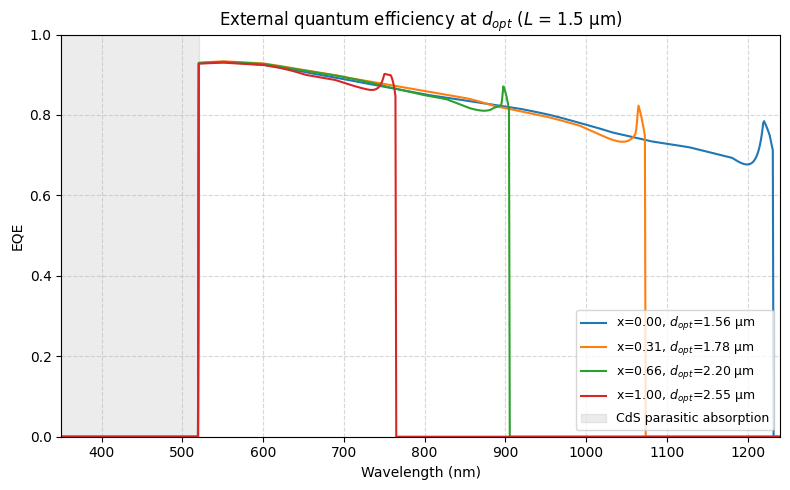

Saved: /content/drive/MyDrive/Colab Notebooks/PV_Layer_Opt/Figures_FINAL/Fig2_EQE_FINAL.pdf
Saved: /content/drive/MyDrive/Colab Notebooks/PV_Layer_Opt/Figures_FINAL/Fig2_EQE_FINAL.png


In [11]:
# Cell 11 — Final Figure 2: EQE at final dopt
# ============================================================
# Final Figure 2: EQE at final d_opt
# ============================================================
L_show = 1.5
x_show_list = [0.00, 0.31, 0.66, 1.00]

plt.figure(figsize=(8, 5))

for x in x_show_list:
    if x not in x_vals:
        continue

    d_opt_um = optima_final[L_show][x]["d_opt"]
    d_opt_m = d_opt_um * 1e-6

    r = device_metrics_model(
        x=x,
        d=d_opt_m,
        L_um=L_show,
        form="quadratic",
        alpha_pen=1.0
    )

    EQE = r["EQE"].copy()

    # Display convention: photons below 520 nm are parasitically absorbed in CdS.
    EQE_display = np.where(wl_nm < CdS_CUTOFF_NM, 0.0, EQE)

    plt.plot(
        wl_nm,
        EQE_display,
        label=f"x={x:.2f}, $d_{{opt}}$={d_opt_um:.2f} µm"
    )

plt.axvspan(
    350, CdS_CUTOFF_NM,
    color="gray",
    alpha=0.15,
    label="CdS parasitic absorption"
)

plt.xlabel("Wavelength (nm)")
plt.ylabel("EQE")
plt.title(f"External quantum efficiency at $d_{{opt}}$ ($L$ = {L_show} µm)")
plt.xlim(350, 1240)
plt.ylim(0, 1.0)
plt.grid(True, linestyle="--", alpha=0.5)
plt.legend(fontsize=9)
plt.tight_layout()

fig2_pdf = os.path.join(FIG_DIR, "Fig2_EQE_FINAL.pdf")
fig2_png = os.path.join(FIG_DIR, "Fig2_EQE_FINAL.png")

plt.savefig(fig2_pdf)
plt.savefig(fig2_png, dpi=300)
plt.show()

print("Saved:", fig2_pdf)
print("Saved:", fig2_png)


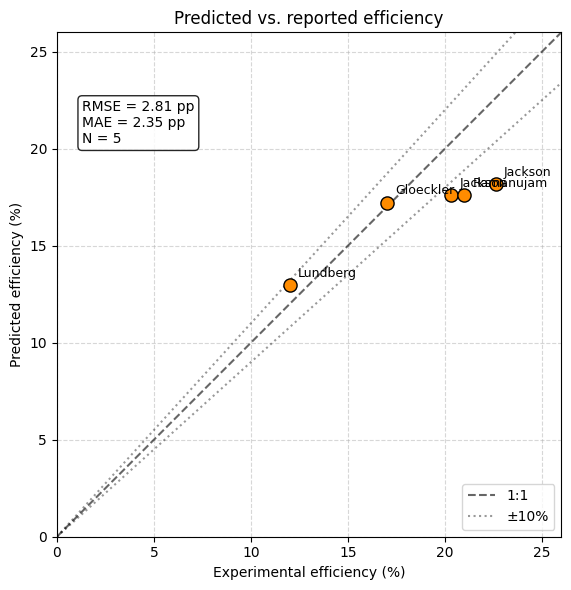

Final parity metrics:
RMSE = 2.81 pp
MAE  = 2.35 pp
Saved: /content/drive/MyDrive/Colab Notebooks/PV_Layer_Opt/Figures_FINAL/Fig3_Parity_FINAL.pdf
Saved: /content/drive/MyDrive/Colab Notebooks/PV_Layer_Opt/Figures_FINAL/Fig3_Parity_FINAL.png


In [12]:
# Cell 12 — Final Figure 3: parity plot from final validation

# ============================================================
# Final Figure 3: final-model parity plot
# ============================================================
exp_eta = np.array([r[6] for r in final_validation])
pred_eta = np.array([r[7] for r in final_validation])
sources = [r[0] for r in final_validation]

rmse = np.sqrt(np.mean((pred_eta - exp_eta)**2))
mae = np.mean(np.abs(pred_eta - exp_eta))

fig, ax = plt.subplots(figsize=(6, 6))

ax.scatter(
    exp_eta,
    pred_eta,
    s=90,
    color="darkorange",
    edgecolor="black",
    zorder=3
)

for i, src in enumerate(sources):
    label = src.split()[0]
    ax.annotate(
        label,
        (exp_eta[i], pred_eta[i]),
        xytext=(6, 6),
        textcoords="offset points",
        fontsize=9
    )

lim_max = max(exp_eta.max(), pred_eta.max()) * 1.15
lim = [0, lim_max]

ax.plot(lim, lim, "k--", alpha=0.6, label="1:1")
ax.plot(lim, [1.1 * v for v in lim], "k:", alpha=0.4, label="±10%")
ax.plot(lim, [0.9 * v for v in lim], "k:", alpha=0.4)

ax.set_xlim(lim)
ax.set_ylim(lim)
ax.set_aspect("equal")
ax.set_xlabel("Experimental efficiency (%)")
ax.set_ylabel("Predicted efficiency (%)")
ax.set_title("Predicted vs. reported efficiency")

ax.text(
    0.05, 0.78,
    f"RMSE = {rmse:.2f} pp\nMAE = {mae:.2f} pp\nN = {len(exp_eta)}",
    transform=ax.transAxes,
    bbox=dict(boxstyle="round", facecolor="white", alpha=0.85),
    fontsize=10
)

ax.legend(loc="lower right")
ax.grid(True, linestyle="--", alpha=0.5)
plt.tight_layout()

fig3_pdf = os.path.join(FIG_DIR, "Fig3_Parity_FINAL.pdf")
fig3_png = os.path.join(FIG_DIR, "Fig3_Parity_FINAL.png")

plt.savefig(fig3_pdf)
plt.savefig(fig3_png, dpi=300)
plt.show()

print("Final parity metrics:")
print(f"RMSE = {rmse:.2f} pp")
print(f"MAE  = {mae:.2f} pp")
print("Saved:", fig3_pdf)
print("Saved:", fig3_png)


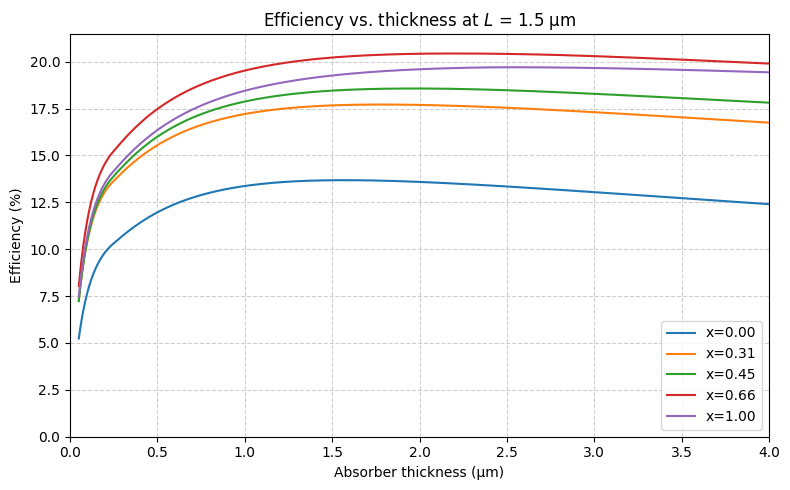

Saved: /content/drive/MyDrive/Colab Notebooks/PV_Layer_Opt/Figures_FINAL/Fig4_Eff_vs_d_FINAL.pdf
Saved: /content/drive/MyDrive/Colab Notebooks/PV_Layer_Opt/Figures_FINAL/Fig4_Eff_vs_d_FINAL.png


In [13]:
# Cell 13 — Final Figure 4: efficiency vs thickness at L=1.5 um
# ============================================================
# Final Figure 4: Efficiency vs thickness at L=1.5 µm
# Cropped to 0–4 µm to focus on relevant design regime.
# ============================================================
plt.figure(figsize=(8, 5))

for x in x_vals:
    plt.plot(
        thickness_um,
        results_final[1.5][x]["eta"],
        label=f"x={x:.2f}"
    )

plt.xlabel("Absorber thickness (µm)")
plt.ylabel("Efficiency (%)")
plt.title("Efficiency vs. thickness at $L$ = 1.5 µm")
plt.xlim(0, 4.0)
plt.ylim(bottom=0)
plt.grid(True, linestyle="--", alpha=0.6)
plt.legend()
plt.tight_layout()

fig4_pdf = os.path.join(FIG_DIR, "Fig4_Eff_vs_d_FINAL.pdf")
fig4_png = os.path.join(FIG_DIR, "Fig4_Eff_vs_d_FINAL.png")

plt.savefig(fig4_pdf)
plt.savefig(fig4_png, dpi=300)
plt.show()

print("Saved:", fig4_pdf)
print("Saved:", fig4_png)


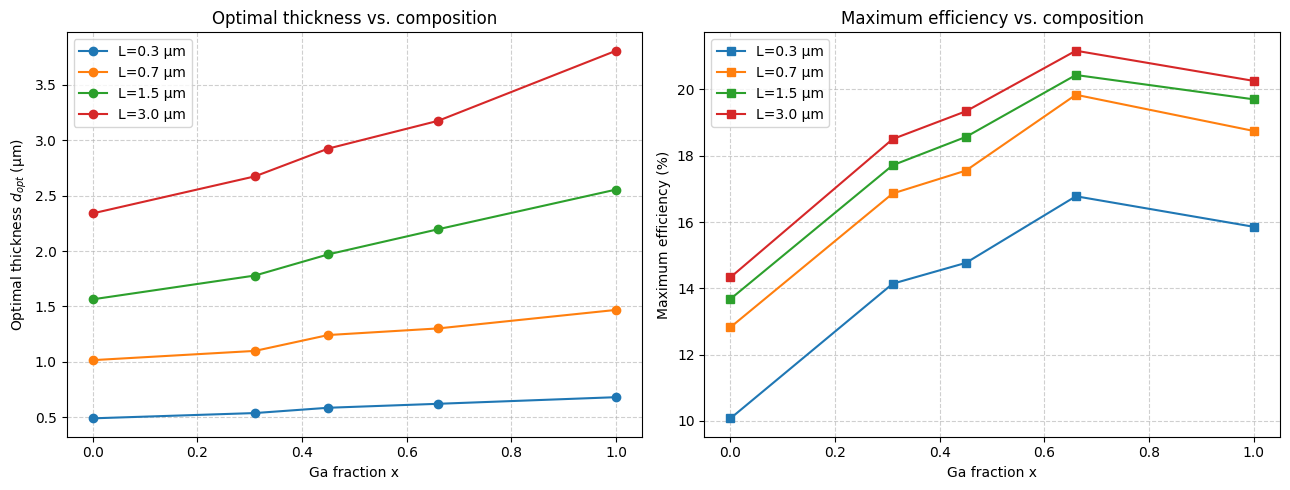

Saved: /content/drive/MyDrive/Colab Notebooks/PV_Layer_Opt/Figures_FINAL/Fig5_DesignMaps_FINAL.pdf
Saved: /content/drive/MyDrive/Colab Notebooks/PV_Layer_Opt/Figures_FINAL/Fig5_DesignMaps_FINAL.png


In [14]:
# Cell 14 — Final Figure 5: dopt and etamax maps
# ============================================================
# Final Figure 5: Design maps
# ============================================================
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for L_um in L_um_list:
    d_opt = [optima_final[L_um][x]["d_opt"] for x in x_vals]
    eta_max = [optima_final[L_um][x]["eta_max"] for x in x_vals]

    axes[0].plot(x_vals, d_opt, "o-", label=f"L={L_um} µm")
    axes[1].plot(x_vals, eta_max, "s-", label=f"L={L_um} µm")

axes[0].set_xlabel("Ga fraction x")
axes[0].set_ylabel("Optimal thickness $d_{opt}$ (µm)")
axes[0].set_title("Optimal thickness vs. composition")

axes[1].set_xlabel("Ga fraction x")
axes[1].set_ylabel("Maximum efficiency (%)")
axes[1].set_title("Maximum efficiency vs. composition")

for ax in axes:
    ax.grid(True, linestyle="--", alpha=0.6)
    ax.legend()

plt.tight_layout()

fig5_pdf = os.path.join(FIG_DIR, "Fig5_DesignMaps_FINAL.pdf")
fig5_png = os.path.join(FIG_DIR, "Fig5_DesignMaps_FINAL.png")

plt.savefig(fig5_pdf)
plt.savefig(fig5_png, dpi=300)
plt.show()

print("Saved:", fig5_pdf)
print("Saved:", fig5_png)


FINAL SENSITIVITY ANALYSIS
Base efficiency = 17.547 %
------------------------------------------------------------------------------------------
Parameter               low         high    eta_low   eta_high      span%
$n_{ideal}$        1.20e+00     1.80e+00     22.571     12.808     -55.64
$S_{back}$         1.00e+03     1.00e+06     15.702     17.977      12.96
$R_{front}$        4.00e-02     1.50e-01     18.573     16.341     -12.72
$W_{dep}$          1.00e-07     4.00e-07     16.653     17.942       7.35
$R_{back}$         5.00e-01     9.50e-01     17.506     17.580       0.42


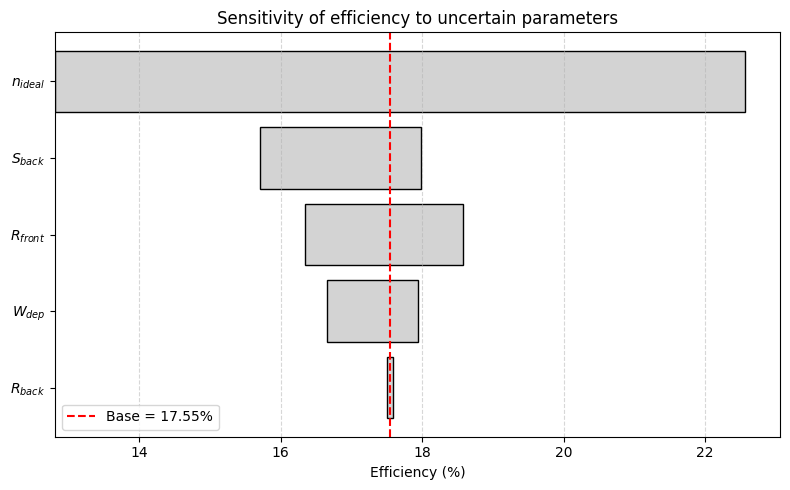

Saved: /content/drive/MyDrive/Colab Notebooks/PV_Layer_Opt/Results_FINAL/sensitivity_final.csv
Saved: /content/drive/MyDrive/Colab Notebooks/PV_Layer_Opt/Figures_FINAL/Fig6_Sensitivity_FINAL.pdf
Saved: /content/drive/MyDrive/Colab Notebooks/PV_Layer_Opt/Figures_FINAL/Fig6_Sensitivity_FINAL.png


In [15]:
# Cell 15 — Final Figure 6: sensitivity tornado using final model
# ============================================================
# Final sensitivity analysis using final model
# ============================================================
x0 = 0.30
L0_um = 1.5
d0_m = 1.5e-6

def eta_final_with(R_front_scalar=None,
                   R_back=R_BACK,
                   W=W_DEP,
                   S_b=S_BACK_CM_S,
                   n=N_IDEALITY):
    if R_front_scalar is None:
        R_front_l = R_FRONT_lambda_TMM
    else:
        R_front_l = np.full_like(wl_nm, R_front_scalar)

    r = device_metrics_model(
        x=x0,
        d=d0_m,
        L_um=L0_um,
        form="quadratic",
        alpha_pen=1.0,
        W=W,
        S_b=S_b,
        n=n,
        R_s=R_S_SI,
        R_back=R_back,
        R_front_l=R_front_l
    )

    return r["eta"]

base_eta = eta_final_with()

sens_params = [
    ("$n_{ideal}$", "n", 1.2, 1.8),
    ("$S_{back}$", "S_b", 1e3, 1e6),
    ("$R_{front}$", "R_front_scalar", 0.04, 0.15),
    ("$W_{dep}$", "W", 0.10e-6, 0.40e-6),
    ("$R_{back}$", "R_back", 0.50, 0.95),
]

sensitivity_rows = []

print("=" * 90)
print("FINAL SENSITIVITY ANALYSIS")
print("=" * 90)
print(f"Base efficiency = {base_eta:.3f} %")
print("-" * 90)
print(f"{'Parameter':<14s} {'low':>12s} {'high':>12s} {'eta_low':>10s} {'eta_high':>10s} {'span%':>10s}")

for label, kw, lo, hi in sens_params:
    eta_lo = eta_final_with(**{kw: lo})
    eta_hi = eta_final_with(**{kw: hi})
    span = 100.0 * (eta_hi - eta_lo) / base_eta

    sensitivity_rows.append((label, kw, lo, hi, eta_lo, eta_hi, span))

    print(f"{label:<14s} {lo:12.2e} {hi:12.2e} {eta_lo:10.3f} {eta_hi:10.3f} {span:10.2f}")

# Sort by absolute span for plotting
sensitivity_rows_sorted = sorted(sensitivity_rows, key=lambda r: abs(r[6]), reverse=True)

labels = [r[0] for r in sensitivity_rows_sorted]
eta_lows = np.array([r[4] for r in sensitivity_rows_sorted])
eta_highs = np.array([r[5] for r in sensitivity_rows_sorted])
lefts = np.minimum(eta_lows, eta_highs)
widths = np.abs(eta_highs - eta_lows)

ypos = np.arange(len(labels))

fig, ax = plt.subplots(figsize=(8, 5))

ax.barh(
    ypos,
    widths,
    left=lefts,
    color="lightgray",
    edgecolor="black"
)

ax.axvline(
    base_eta,
    color="red",
    linestyle="--",
    label=f"Base = {base_eta:.2f}%"
)

ax.set_yticks(ypos)
ax.set_yticklabels(labels)
ax.invert_yaxis()
ax.set_xlabel("Efficiency (%)")
ax.set_title("Sensitivity of efficiency to uncertain parameters")
ax.grid(axis="x", linestyle="--", alpha=0.5)
ax.legend()

plt.tight_layout()

fig6_pdf = os.path.join(FIG_DIR, "Fig6_Sensitivity_FINAL.pdf")
fig6_png = os.path.join(FIG_DIR, "Fig6_Sensitivity_FINAL.png")

plt.savefig(fig6_pdf)
plt.savefig(fig6_png, dpi=300)
plt.show()

# Save sensitivity table
sens_csv = os.path.join(RESULTS_DIR, "sensitivity_final.csv")
with open(sens_csv, "w", newline="", encoding="utf-8") as f:
    writer = csv.writer(f)
    writer.writerow(["label", "parameter", "low", "high", "eta_low", "eta_high", "span_percent_of_base"])
    writer.writerows(sensitivity_rows)

print("Saved:", sens_csv)
print("Saved:", fig6_pdf)
print("Saved:", fig6_png)


In [16]:
# Cell 16 — Final manuscript numbers summary
# ============================================================
# Final manuscript numbers summary
# ============================================================
print("=" * 100)
print("FINAL MANUSCRIPT NUMBERS")
print("=" * 100)

print("\nValidation:")
print(f"MAE d_opt = {mae_d:.1f} %")
print(f"MAE eta   = {mae_eta_pp:.2f} pp")
print(f"RMSE eta  = {rmse_eta_pp:.2f} pp")

print("\nS-Q audit:")
print(f"S-Q violations = {n_violations} / {len(sq_rows)}")

print("\nModel-form comparison:")
for form in forms:
    a, cost, ed, ee = best_per_form[form]
    print(f"{form:10s}: alpha={a:.2f}, MAE_d={100*ed:.1f}%, MAE_eta={100*ee:.1f}%, cost={cost:.3f}")

print("\nFinal design range:")
all_d = [row[2] for row in design_rows]
all_eta = [row[3] for row in design_rows]

print(f"d_opt range = {min(all_d):.3f} to {max(all_d):.3f} µm")
print(f"eta range   = {min(all_eta):.2f} to {max(all_eta):.2f} %")

print("\nPer-L maximum composition:")
for L_um in L_um_list:
    xs = []
    etas = []
    for x in x_vals:
        xs.append(x)
        etas.append(optima_final[L_um][x]["eta_max"])
    idx = int(np.argmax(etas))
    print(f"L={L_um:.2f} µm: max at x={xs[idx]:.2f}, eta={etas[idx]:.2f}%")

print("\nFinal figure files saved in:")
print(FIG_DIR)

print("\nFinal result CSV files saved in:")
print(RESULTS_DIR)


FINAL MANUSCRIPT NUMBERS

Validation:
MAE d_opt = 15.1 %
MAE eta   = 2.35 pp
RMSE eta  = 2.81 pp

S-Q audit:
S-Q violations = 0 / 18

Model-form comparison:
linear    : alpha=4.60, MAE_d=20.1%, MAE_eta=15.7%, cost=0.179
quadratic : alpha=1.00, MAE_d=15.1%, MAE_eta=11.7%, cost=0.134
shockley  : alpha=3.40, MAE_d=40.2%, MAE_eta=14.0%, cost=0.271

Final design range:
d_opt range = 0.491 to 3.806 µm
eta range   = 10.08 to 21.17 %

Per-L maximum composition:
L=0.30 µm: max at x=0.66, eta=16.78%
L=0.70 µm: max at x=0.66, eta=19.84%
L=1.50 µm: max at x=0.66, eta=20.44%
L=3.00 µm: max at x=0.66, eta=21.17%

Final figure files saved in:
/content/drive/MyDrive/Colab Notebooks/PV_Layer_Opt/Figures_FINAL

Final result CSV files saved in:
/content/drive/MyDrive/Colab Notebooks/PV_Layer_Opt/Results_FINAL


In [18]:
# Cell 17 — Optional: package check for repository
# ============================================================
# Repository / Zenodo checklist
# ============================================================
print("Recommended repository contents:")
print("""
README.md
requirements.txt
LICENSE
notebooks/
    CIGS_Model_Final_Production.ipynb
data/
    README.md
""")

print("Zenodo DOI:")
print("https://doi.org/10.5281/zenodo.20325908")

print("\nRecommended Data and Code Availability statement:")
print("""
The Google Colab notebook implementing the coupled optical–electrical CIGS absorber-thickness
optimization model is archived on Zenodo at https://doi.org/10.5281/zenodo.20325908.
The optical constants used as model input were obtained from the experimental CuIn1-xGaxSe2
measurements reported by Paulson et al. and should be cited through the original source
publication. The raw Paulson optical-constant files are not redistributed in the archive;
instructions for obtaining and placing the source files are provided in the repository
data/README.md file.
""")


Recommended repository contents:

README.md
requirements.txt
LICENSE
notebooks/
    CIGS_Model_Final_Production.ipynb
data/
    README.md

Zenodo DOI:
https://doi.org/10.5281/zenodo.20325908

Recommended Data and Code Availability statement:

The Google Colab notebook implementing the coupled optical–electrical CIGS absorber-thickness
optimization model is archived on Zenodo at https://doi.org/10.5281/zenodo.20325908.
The optical constants used as model input were obtained from the experimental CuIn1-xGaxSe2
measurements reported by Paulson et al. and should be cited through the original source
publication. The raw Paulson optical-constant files are not redistributed in the archive;
instructions for obtaining and placing the source files are provided in the repository
data/README.md file.

